# Задание 1.

Реализуйте базовый класс **Account**, который моделирует поведение банковского счёта.  
Этот класс должен не только выполнять базовые операции, но и вести детальный учёт всех действий, а также предоставлять аналитику по истории операций.

---

## Этап 1. Реализация базового класса Account

Класс должен быть инициализирован с параметрами:

- **account_holder (str)** — имя владельца счёта;
- **balance (float, по умолчанию 0)** — начальный баланс счёта, не может быть отрицательным.

### Атрибуты:

- **_account_counter** — приватный атрибут для хранения количества созданных счетов. Отсчет начинается с 1000;
- **holder** — хранит имя владельца;
- **account_number** — хранит номер счёта;
- **_balance** — приватный атрибут для хранения текущего баланса;
- **operations_history** — список или другая структура для хранения истории операций.

**Важно:**  
Каждая операция должна храниться не просто как число, а как структурированная информация, например, словарь, кортеж или класс.  
Минимальный набор данных для операции:  
тип операции ('deposit' или 'withdraw'), сумма, дата и время операции, текущий баланс после операции, статус ('success' или 'fail').

---

## Этап 2. Реализация методов

1. **__init__(self, account_holder, balance=0)** — конструктор.  
   Обратите внимание, что в конструкторе должен автоматически формироваться номер счёта в формате ‘ACC-XXXX’, где XXXX — порядковый номер счёта;

2. **deposit(self, amount)** — метод для пополнения счёта:  
   - принимает сумму (должна быть положительной), попытка положить отрицательную сумму должна вызывать исключение;  
   - в случае успеха обновляет баланс и добавляет запись в историю операций.

3. **withdraw(self, amount)** — метод для снятия средств:  
   - принимает сумму (должна быть положительной);  
   - проверяет, достаточно ли средств на счёте, если нет — операция не проходит, но её попытка со статусом 'fail' всё равно фиксируется в истории;  
   - в случае успеха обновляет баланс и добавляет запись в историю.

4. **get_balance(self)** — метод, который возвращает текущий баланс.  
5. **get_history(self)** — метод, который возвращает историю операций.  

**Важно:** продумайте, в каком формате его вернуть.  
Для работы с датой и временем используйте модуль `datetime`.  
Получить текущее время можно с помощью `datetime.now()`.

---

## Этап 3. Визуализация истории операций  
*(Дополнительное задание для претендующих на оценку 8 и выше баллов, выполняется по желанию.)*

1. Создайте метод **plot_history(self)**, который использует библиотеку Pandas для создания датафрейма из истории операций.  
2. Продумайте, с помощью какой библиотеки можно отобразить изменение баланса с течением времени.  
   Постройте простой линейный график, где по оси X будет время операции, а по оси Y — баланс после каждой операции.  
   График должен иметь заголовок и подписи осей.

---

# Задание 2.

## Этап 4. Реализация наследования

1. Реализуйте два класса **CheckingAccount (расчётный счёт)** и **SavingsAccount (сберегательный счёт)**, которые отражают абстракцию базового поведения банковских аккаунтов:  
   - наследуются от базового класса Account;  
   - хранят атрибут класса `account_type`.

2. Класс **SavingsAccount (сберегательный счёт)** дополнительно должен реализовывать метод расчёта процентов на остаток **apply_interest(self, rate)** (например, 7% на остаток).

3. Класс **SavingsAccount (сберегательный счёт)** позволяет снимать деньги только до определённого порога баланса: нельзя снять больше 50% от баланса.  
   Переопределите метод снятия со счёта.

4. Реализуйте валидацию на отрицательные суммы и корректность имени владельца:  
   - имя владельца счёта должно быть в формате «Имя Фамилия» с заглавных букв, кириллицей или латиницей, иначе должно вызываться исключение;  
   - попытка положить отрицательную сумму должна вызывать исключение.

5. Реализуйте метод для анализа истории транзакций по размеру и дате:  
   - метод должен выводить последние n крупных операций.

---

# Задание 3.  
## Дополнительное задание для претендующих на оценку 9–10 баллов *(выполняется по желанию).*

Перед началом работы загрузите из личного кабинета файлы, на которых можно проверить код с «грязными» данными:  
**transactions_dirty.csv** и **transactions_dirty.json**.

Реализуйте для классов аккаунтов **CheckingAccount (расчётный счёт)** и **SavingsAccount (сберегательный счёт)** два метода:

- **Метод загрузки истории в аккаунт из файла с транзакциями**  
  (файл транзакций общий для всех аккаунтов, необходимо учесть фильтрацию загружаемых значений).

- **Метод clean_history()**, который ищет ошибки в данных перед записью транзакций в историю  
  (опечатки, отрицательные суммы, неверные даты).  
  Обратите внимание, что для **SavingsAccount (сберегательный счёт)** доступно три типа операции (`deposit`, `withdraw` и `interest`),  
  в то время как для **CheckingAccount (расчётный счёт)** доступны только два типа операции (`deposit`, `withdraw`).  
  Все данные с ошибками считаем невалидными и не записываем в историю операций.

- После загрузки истории операций в аккаунт, баланс счёта должен обновиться.


In [26]:
from datetime import datetime
import os
import re
import json
import pandas as pd
import matplotlib.pyplot as plt



class Operation:
    def __init__(self, account_type, operation_type, amount,
                 balance_after, status, date=None):
        self.operation_type = operation_type
        self.amount = amount
        self.time = date if date else datetime.now()
        self.balance_after = balance_after
        self.status = status
        self.account_type = account_type

    def __repr__(self):
        return (
            f"[{self.account_type}] "
            f"{self.time:%Y-%m-%d %H:%M:%S} | "
            f"{self.operation_type} {self.amount} | "
            f"Баланс: {self.balance_after} | {self.status}"
        )


class Account:
    _account_counter = 100000
    ALLOWED_OPS = {"deposit", "withdraw"}

    @staticmethod
    def _validate_holder(name: str):
        pattern = (
            r'^(?:[A-Z][a-z]+ [A-Z][a-z]+|'
            r'[А-ЯЁ][а-яё]+ [А-ЯЁ][а-яё]+)$'
        )
        if not re.fullmatch(pattern, name):
            raise ValueError(
                "Имя владельца должно быть в формате "
                "'Имя Фамилия' с заглавных букв "
                "(латиница или кириллица)."
            )

    def __init__(self, account_holder, balance=0):
        if balance < 0:
            raise ValueError("Баланс не может быть отрицательным")

        Account._validate_holder(account_holder)

        self.holder = account_holder
        self._balance = balance
        Account._account_counter += 1
        self.account_number = f'ACC-{Account._account_counter}'
        self.operations_history = []

    def deposit(self, amount):
        if amount <= 0:
            raise ValueError('Сумма депозита должна быть положительной')

        self._balance += amount
        self.operations_history.append(
            Operation(
                self.account_type, 'deposit', amount,
                self._balance, 'success'
            )
        )

    def withdraw(self, amount):
        if amount <= 0:
            raise ValueError('Сумма снятия должна быть положительной')

        if self._balance - amount < 0:
            self.operations_history.append(
                Operation(
                    self.account_type, 'withdraw', amount,
                    self._balance, 'fail'
                )
            )
        else:
            self._balance -= amount
            self.operations_history.append(
                Operation(
                    self.account_type, 'withdraw', amount,
                    self._balance, 'success'
                )
            )

    def get_balance(self):
        return self._balance

    def get_history(self):
        return self.operations_history

    def plot_history(self):
        if not self.operations_history:
            print("История пуста, нечего визуализировать.")
            return

        df = pd.DataFrame([
            {
                "Время": op.time,
                "Баланс после операции": op.balance_after
            }
            for op in self.operations_history
        ])

        df = df.sort_values("Время")

        plt.figure(figsize=(7, 4))
        plt.plot(df["Время"], df["Баланс после операции"], marker="o")
        plt.title(f"Изменение баланса счёта {self.account_number}")
        plt.xlabel("Время операции")
        plt.ylabel("Баланс (₽)")
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def recent_operations(self, n=5,
                          min_amount: float = 100000,
                          only_success: bool = True):
        ops = self.operations_history

        if only_success:
            ops = [op for op in ops if op.status == 'success']

        ops = [op for op in ops if abs(op.amount) >= min_amount]
        ops.sort(key=lambda op: op.time, reverse=True)
        return ops[:n]

    def load_history_from_file(self, path):
        if not os.path.exists(path):
            raise FileNotFoundError('Файл не найден')

        ext = os.path.splitext(path)[1].lower()
        if ext == '.csv':
            data_raw = pd.read_csv(path)
        elif ext == '.json':
            with open(path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            data_raw = pd.DataFrame(data)
        else:
            raise ValueError(
                'Поддерживаемые расширения файлов .csv и .json'
            )

        df = self.clean_history(data_raw)
        if df.empty:
            return

        for _, row in df.iterrows():
            op = str(row["operation"]).lower()
            amount = float(row["amount"])
            balance_after = float(row["balance_after"])
            date = row["date"].to_pydatetime()
            status = str(row["status"])

            self.operations_history.append(
                Operation(
                    self.account_type, op, amount,
                    balance_after, status, date=date
                )
            )

        self._balance = float(df.iloc[-1]["balance_after"])

    def clean_history(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.dropna(
            subset=[
                "account_number", "account_type", "date",
                "operation", "amount", "balance_after", "status"
            ]
        )

        df = df[df["account_number"].astype(str) == str(self.account_number)]
        df = df[
            df["account_type"].astype(str).str.lower()
            == self.account_type.lower()
        ]

        df = df[df["operation"].isin(self.ALLOWED_OPS)]
        df = df[df["status"].astype(str).str.lower() == "success"]

        df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
        df["balance_after"] = pd.to_numeric(df["balance_after"], errors="coerce")
        df = df[(df["amount"].notna()) & (df["amount"] > 0)]
        df = df[df["balance_after"].notna()]

        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        now = pd.Timestamp.now()
        df = df[df["date"].notna() & (df["date"] <= now)]

        df = df.sort_values("date").reset_index(drop=True)

        return df[["date", "operation", "amount", "balance_after", "status"]]


class SavingsAccount(Account):
    account_type = 'savings'
    ALLOWED_OPS = {"deposit", "withdraw", "interest"}

    def apply_interest(self, rate):
        if rate < 0:
            raise ValueError("Ставка не может быть отрицательной")

        interest = self._balance * (rate / 100)
        self._balance += interest
        self.operations_history.append(
            Operation(
                self.account_type, 'interest', interest,
                self._balance, 'success'
            )
        )

    def withdraw(self, amount):
        if amount <= 0:
            raise ValueError('Сумма снятия должна быть положительной')

        if amount > self._balance * 0.5:
            self.operations_history.append(
                Operation(
                    self.account_type, 'withdraw', amount,
                    self._balance, 'fail'
                )
            )
        else:
            self._balance -= amount
            self.operations_history.append(
                Operation(
                    self.account_type, 'withdraw', amount,
                    self._balance, 'success'
                )
            )


class CheckingAccount(Account):
    account_type = 'checking'


# Проверим выполнение всех заданий


История оперций расчетного счета:
Номер счёта: ACC-100001
Текущий баланс: 7959.0
Всего операций: 16
Последние 3 операции:
   [checking] 2025-10-16 22:17:26 | withdraw 393.0 | Баланс: 7431.0 | success
   [checking] 2025-10-17 22:17:26 | withdraw 308.0 | Баланс: 7824.0 | success
   [checking] 2025-10-18 22:17:26 | deposit 135.0 | Баланс: 7959.0 | success

История оперций сберегательного счета:
Номер счёта: ACC-100002
Текущий баланс: 5605.79
Всего операций: 16
Последние 3 операции:
   [savings] 2025-10-17 22:17:26 | withdraw 286.0 | Баланс: 6342.66 | success
   [savings] 2025-10-20 22:17:26 | interest 302.13 | Баланс: 6344.79 | success
   [savings] 2025-10-23 22:17:26 | withdraw 282.0 | Баланс: 5605.79 | success

Рисуем график расчетного счета:


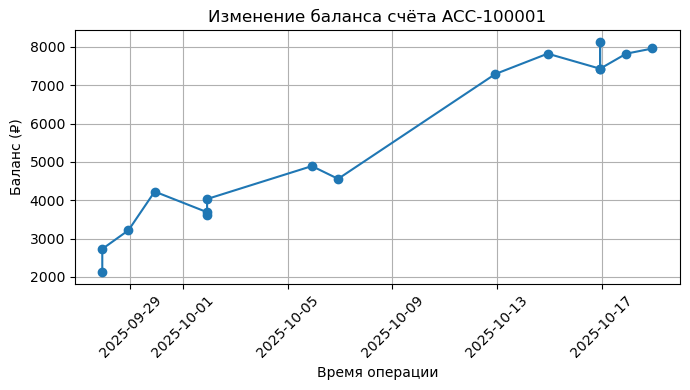


Рисуем график сберегательного счета:


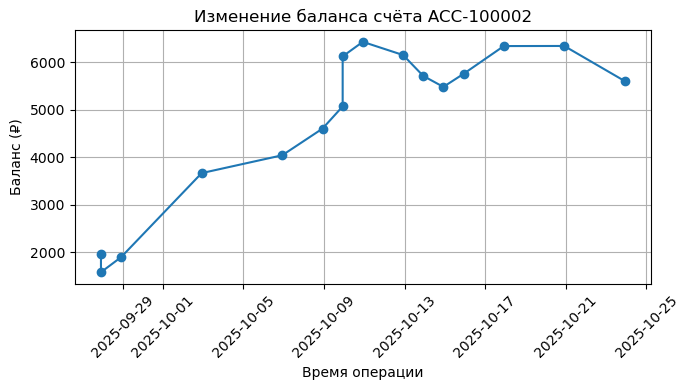


История оперций расчетного счета:
Номер счёта: ACC-100001
Текущий баланс: 8089.0
Всего операций: 18
Последние 3 операции:
   [checking] 2025-10-18 22:17:26 | deposit 135.0 | Баланс: 7959.0 | success
   [checking] 2025-11-07 21:46:05 | deposit 250 | Баланс: 8209.0 | success
   [checking] 2025-11-07 21:46:05 | withdraw 120 | Баланс: 8089.0 | success

История оперций сберегательного счета:
Номер счёта: ACC-100002
Текущий баланс: 6306.0795
Всего операций: 20
Последние 3 операции:
   [savings] 2025-11-07 21:46:05 | withdraw 3663.4739999999997 | Баланс: 6105.79 | fail
   [savings] 2025-11-07 21:46:05 | withdraw 100 | Баланс: 6005.79 | success
   [savings] 2025-11-07 21:46:05 | interest 300.28950000000003 | Баланс: 6306.0795 | success

Рисуем график расчетного счета:


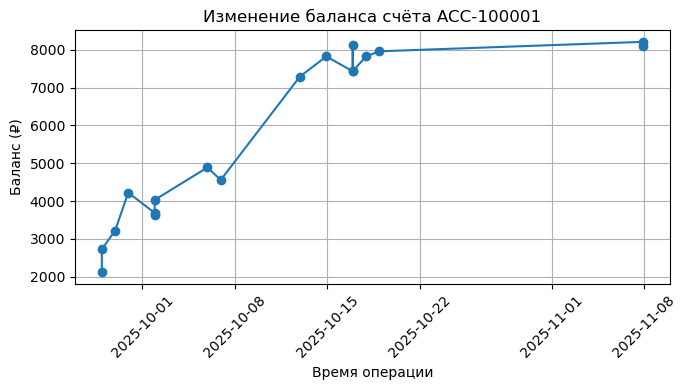


Рисуем график сберегательного счета:


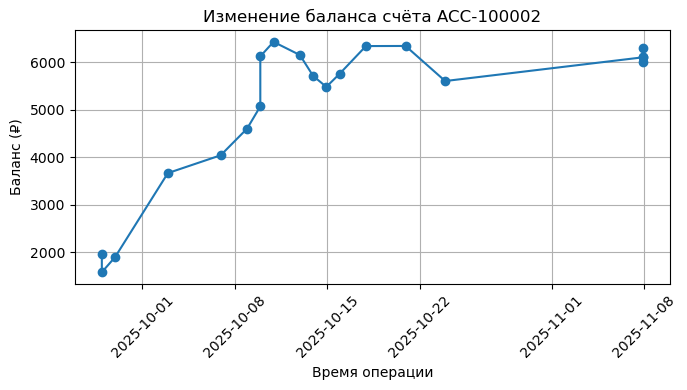


Крупные операции расчетного счета:
   [checking] 2025-10-16 22:17:26 | deposit 701.0 | Баланс: 8132.0 | success
   [checking] 2025-10-14 22:17:26 | deposit 532.0 | Баланс: 7824.0 | success
   [checking] 2025-10-12 22:17:26 | deposit 838.0 | Баланс: 7292.0 | success
   [checking] 2025-09-29 22:17:26 | deposit 880.0 | Баланс: 4225.0 | success
   [checking] 2025-09-27 22:17:26 | deposit 921.0 | Баланс: 2121.0 | success

Крупные операции сберегательного счета:
   [savings] 2025-11-07 21:46:05 | deposit 500 | Баланс: 6105.79 | success
   [savings] 2025-10-09 22:17:26 | deposit 622.0 | Баланс: 6125.27 | success
   [savings] 2025-10-02 22:17:26 | deposit 840.0 | Баланс: 3665.55 | success


In [ ]:
PATH = "transactions_dirty.csv"
# PATH = "transactions_dirty.json"

checking = CheckingAccount("Иван Петров")

savings = SavingsAccount("Пётр Иванов")

# Загружаем историю
checking.load_history_from_file(PATH)
savings.load_history_from_file(PATH)

# Вывод информации
def show_statistic(acc):
    print("Номер счёта:", acc.account_number)
    print("Текущий баланс:", acc.get_balance())
    print("Всего операций:", len(acc.get_history()))
    print("Последние 3 операции:")
    for op in acc.get_history()[-3:]:
        print("  ", op)

print('\nИстория оперций расчетного счета:')
show_statistic(checking)
print('\nИстория оперций сберегательного счета:')
show_statistic(savings)

# Графики истории
print("\nРисуем график расчетного счета:")
checking.plot_history()

print("\nРисуем график сберегательного счета:")
savings.plot_history()

# выполняем новые  операции
checking.deposit(250)
checking.withdraw(120)          

savings.deposit(500)
try:
    savings.withdraw(savings.get_balance() * 0.6)   # попытка снять больше, чем разрешено
except Exception as e:
    print("Ошибка при снятии >50% (как и ожидалось):", e)
savings.withdraw(100)          
savings.apply_interest(5)       

# Проверяем состояние счетов после новых операций
print('\nИстория оперций расчетного счета:')
show_statistic(checking)
print('\nИстория оперций сберегательного счета:')
show_statistic(savings)

# Графики истории
print("\nРисуем график расчетного счета:")
checking.plot_history()

print("\nРисуем график сберегательного счета:")
savings.plot_history()

print("\nКрупные операции расчетного счета:")
for op in checking.recent_operations(n=5, min_amount=500):
    print("  ", op)

print("\nКрупные операции сберегательного счета:")
for op in savings.recent_operations(n=5, min_amount=500):
    print("  ", op)

In [14]:
# Проверим некорректное имя владельца аккаунта

checking2 = CheckingAccount("Иван петров")

ValueError: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв (латиница или кириллица).